In [6]:
import numpy as np
from pycvxset import Polytope
from adaptive_tools import SetUpdater


In [22]:
A = np.array(
            [
                [
                    [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 6.55847073e-03,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00]],
                [
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 9.62477033e-01, -2.70418272e-01, -3.54535263e-01, -1.08121033e-01],
                    [ 6.03978994e-02, -3.51946037e-01, -6.16284799e-01, 1.82183285e-01],
                    [-2.98716243e-03, -3.30481599e-02, -3.49541770e-05, 1.52896134e-02]],
                [
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [-4.21460547e-02,  1.48734527e-01,  2.49708275e-01, 1.46475140e-01],
                    [ 9.32949059e-01,  2.33489450e-01,  3.84304411e-01, -1.35325598e-02],
                    [-9.96893529e-03,  1.42242452e-02,  5.02034057e-03, -4.66406071e-02]],
                [
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [-2.59938961e-02, -2.63172399e-02,  4.65109389e-03, 3.00565144e-01],
                    [-1.59201270e-03, -2.02848177e-02, -2.60380154e-02, 3.90983528e-01],
                    [ 8.70485640e-01, -5.48457771e-02,  3.24459921e-02, 6.67191728e-02]]])
B = np.array(
            [
                [
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00]],
                [
                    [ 8.40916986e-02, -6.74379191e-01,  4.14184808e-01, 6.96994653e-02],
                    [ 1.37701713e-02,  2.87919480e-02, -9.12432271e-02, -2.99699931e-01]],
                [
                    [-1.02160995e-02,  5.14789438e-01, -3.00694970e-01, 2.04723249e-01],
                    [ 2.58556998e-04, -4.44445006e-03,  4.10364069e-02, 3.52610402e-01]],
                [
                    [ 2.28217366e-02, -1.76918468e-02,  8.71910634e-02, 6.08327604e-01],
                    [ 1.31207096e-01,  2.19817108e-03,  5.56598339e-02, -2.28968692e-01]]])

C = np.eye(2)
C = np.stack([C, np.zeros((2, 2)), np.zeros((2, 2)), np.zeros((2, 2))], axis=2)

A_B=np.concatenate( (A, B), axis=1).transpose(2, 0, 1)

E = Polytope(
                A=np.vstack((np.eye(2), -np.eye(2))),
                b=np.concatenate((np.ones(2) * 0.01, np.ones(2) * 0.01)),
            )
W = Polytope(
                A=np.block([[np.eye(4)], [-np.eye(4)]]), b=0.05 * np.ones((8, 1))
            )
Theta_c = Polytope(V=np.eye(2))

ValueError: The Polytope is underdefined!

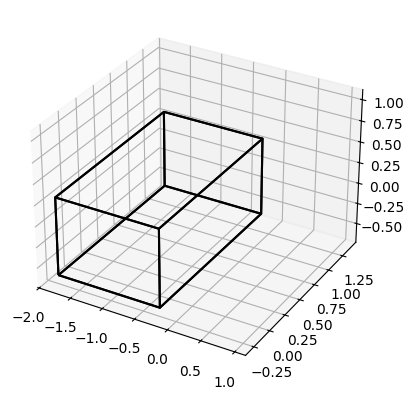

In [25]:
max_p, min_p = ([np.float64(-0.23350), np.float64(1.37460), np.float64(0.31949)], [np.float64(-1.81833),np.float64(-0.26129),np.float64(-0.61740)])

Theta = Polytope(A=np.block([[np.eye(3)], [-np.eye(3)]]), b=np.block([np.array(max_p), -np.array(min_p)]))  # np.block([np.array(max_p), -np.array(min_p)])
Theta.plot()
Theta.V

SetUpdater(A_B, C.transpose(2, 0, 1), Theta, Theta_c, W, E, 1)